In [1]:
from data_utils import *


DATA_ROOT = "../outputs/combined/"
FIGURE_ROOT = Path("../outputs/plots/var_run")
N_RUNS = 100
N_EXAMPLES = 50000

model_df = get_model_df(DATA_ROOT)
MODEL_SUBSET = [
    {"key": "lottery_8ae667adac9b690a88b522e85f1388c8"},
    {"key": "lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5"},
    {"key": "lottery_06562e05cda1bf840ee146490815ed82"},
    {"key": "lottery_9dc2b8dfff54c4da57570d7b391dcccd"},
]
model_df = multi_filter_df(model_df, MODEL_SUBSET)
model_df

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model_key,dataset_key,Model,Dataset,Task,Parameters,path,key,n_replicates
5,cifar_resnet_20,cifar10,ResNet-20,CIFAR-10,CIFAR-10/ResNet-20,272474,../outputs/combined/lottery_8ae667adac9b690a88...,lottery_8ae667adac9b690a88b522e85f1388c8,100
8,cifar_vgg_16,cifar10,VGG-16,CIFAR-10,CIFAR-10/VGG-16,14728266,../outputs/combined/lottery_cf40a5a8bbe4f285b8...,lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5,100
1,cifar_vgg_16,cifar100,VGG-16,CIFAR-100,CIFAR-100/VGG-16,14728266,../outputs/combined/lottery_06562e05cda1bf840e...,lottery_06562e05cda1bf840ee146490815ed82,100
6,cifar_resnet_20,cifar100,ResNet-20,CIFAR-100,CIFAR-100/ResNet-20,272474,../outputs/combined/lottery_9dc2b8dfff54c4da57...,lottery_9dc2b8dfff54c4da57570d7b391dcccd,100


In [2]:
SELECTED_SCORES = [
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
]

ALL_SCORES = [
    {"key": "allacc",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 160},
    {"key": "allacc",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 20},
    {"key": "carlini_agr"},
    {"key": "acc",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "conf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "maxconf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "el2n",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "lossvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "carlini_ret"},
    {"key": "carlini_adv"},
    {"key": "carlini_priv"},
]

ALL_SCORES = [d for d in ALL_SCORES if "carlini" not in d["key"] and "allacc" not in d["key"]]

In [3]:
from itertools import product


def plot_selected_stds(df, n_examples=500, name=None):
    cols = 3
    fig, axes = plt.subplots(4, cols, figsize=(12, 12))
    # don't include loss to make it 6 panels instead of 7
    selected = SELECTED_SCORES[1:]
    for i, (row, score) in enumerate(get_selected_scores(df, selected, n_examples)):
        mean_score = np.mean(score, axis=0)
        mean_quantile = rankdata(mean_score, axis=0) / n_examples

        std = np.std(score, axis=0)
        std_ax = axes[(i // cols) * 2, i % cols]

        sns.scatterplot(y=std, x=mean_quantile, ax=std_ax)
        score_name = row["Short Name"]
        std_ax.set_ylabel("St. Dev.")
        std_ax.set_xlabel(("$-1 \\times$" if row["is_inverted"] else "") + f"Mean {score_name} (Quantile)")

        rank_err = get_rank_err(score, np.expand_dims(mean_score, 0))
        rank_err = np.median(rank_err, axis=0)
        rank_ax = axes[(i // cols) * 2 + 1, i % cols]

        sns.scatterplot(y=rank_err, x=mean_quantile, ax=rank_ax, c="orange")
        rank_ax.set_ylabel("Median Rank Error")
        rank_ax.set_xlabel(("$-1 \\times$" if row["is_inverted"] else "") + f"Mean {score_name} (Quantile)")
    save_fig(FIGURE_ROOT, "mean_std", name=name)


def plot_run_rank_corr(df, subset_only, name=None):
    selected_attrs = SELECTED_SCORES if subset_only else ALL_SCORES
    scores = get_selected_scores(df, selected_attrs)

    matrix, names = [], []
    for row, score in scores:
        mean_score = np.mean(score, axis=0)
        matrix.append(get_corr(score, mean_score))
        names.append(row["Full Name"])
    matrix = np.array(matrix).reshape(-1, 1)
    plot_corr_matrix(matrix, "", "", names, "", ["$\\rho$ Per-Run vs\nMean (100 Runs)"])
    save_fig(FIGURE_ROOT, "rank_corr", name=name, figsize=None if subset_only else (14, 14))


def plot_run_rank_err(df, subset_only, name=None):
    selected_attrs = SELECTED_SCORES if subset_only else ALL_SCORES
    scores = get_selected_scores(df, selected_attrs)

    new_df = []
    for row, score in scores:
        mean_score = np.mean(score, axis=0, keepdims=True)
        rank_err = get_rank_err(score, mean_score)
        new_df.append({
            "Score": row["Full Name"],
            "Rank Error": rank_err.flatten(),
        })
    new_df = pd.DataFrame(new_df)
    new_df = new_df.explode("Rank Error")
    sns.boxplot(data=new_df, x="Rank Error", y="Score", showfliers=False)
    save_fig(FIGURE_ROOT, "rank_err", name=name, figsize=None if subset_only else (7, 10))


def plot_run_subsample_err(df, subset_only, subsamples=[2, 4, 8, 16, 40, 80], n_iters=30, name=None):
    selected_attrs = SELECTED_SCORES if subset_only else ALL_SCORES
    scores = get_selected_scores(df, selected_attrs)

    new_df = []
    for row, score in scores:
        mean_score = np.mean(score, axis=0, keepdims=True)
        n_runs = score.shape[0]
        for n_samples, _ in product(subsamples, range(n_iters)):
            subsample = score[np.random.permutation(n_runs)[:n_samples]]
            subsample_mean = np.mean(subsample, axis=0, keepdims=True)
            new_df.append({
                "Score": row["Full Name"],
                "Runs Sampled ($n$)": n_samples,
                "Median Rank Error": np.median(get_rank_err(subsample_mean, mean_score)),
            })
    ax = sns.lineplot(data=pd.DataFrame(new_df), x="Runs Sampled ($n$)", y="Median Rank Error", hue="Score")
    ax.plot(np.linspace(1, 80, 80), 0.12 / np.sqrt(np.linspace(1, 80, 80)), linestyle="dotted", label="$O(n^{-2})$", color="grey")
    ax.legend()
    ax.set_ylim(0, 0.12)
    save_fig(FIGURE_ROOT, "run_subsample_err", name=name)

model_key                                         cifar_resnet_20
dataset_key                                               cifar10
Model                                                   ResNet-20
Dataset                                                  CIFAR-10
Task                                           CIFAR-10/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_8ae667adac9b690a88...
key                      lottery_8ae667adac9b690a88b522e85f1388c8
n_replicates                                                  100
Name: 5, dtype: object
Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_mean_std.pdf


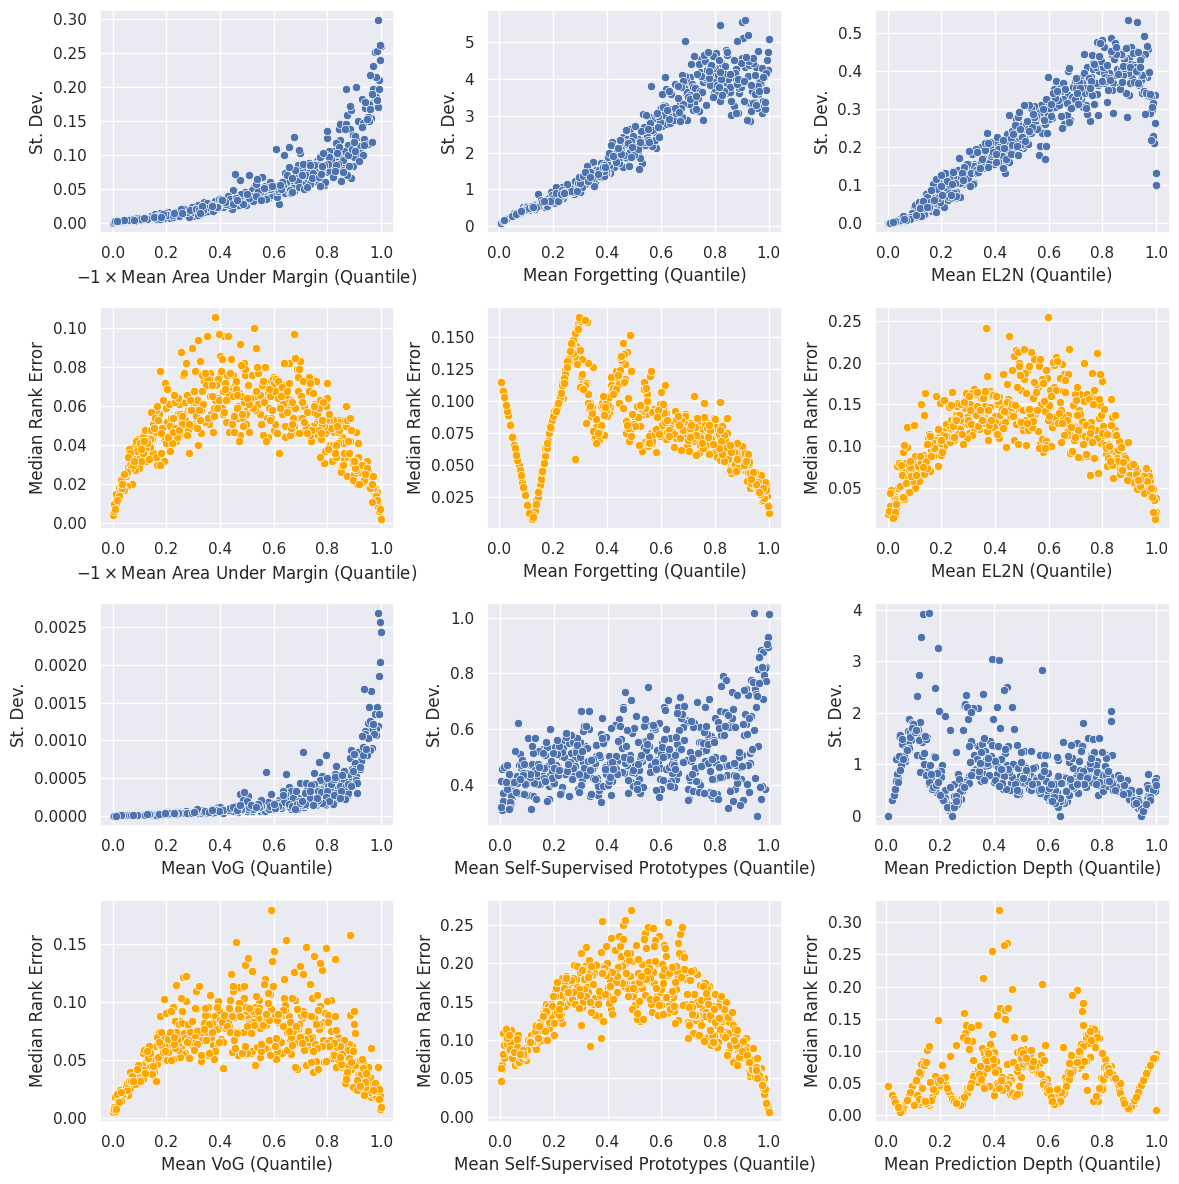

Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_selected_rank_corr.pdf


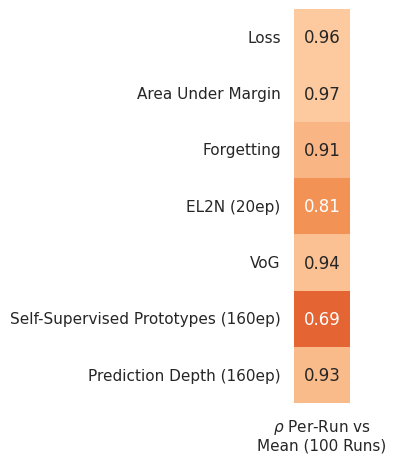

Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_rank_corr.pdf


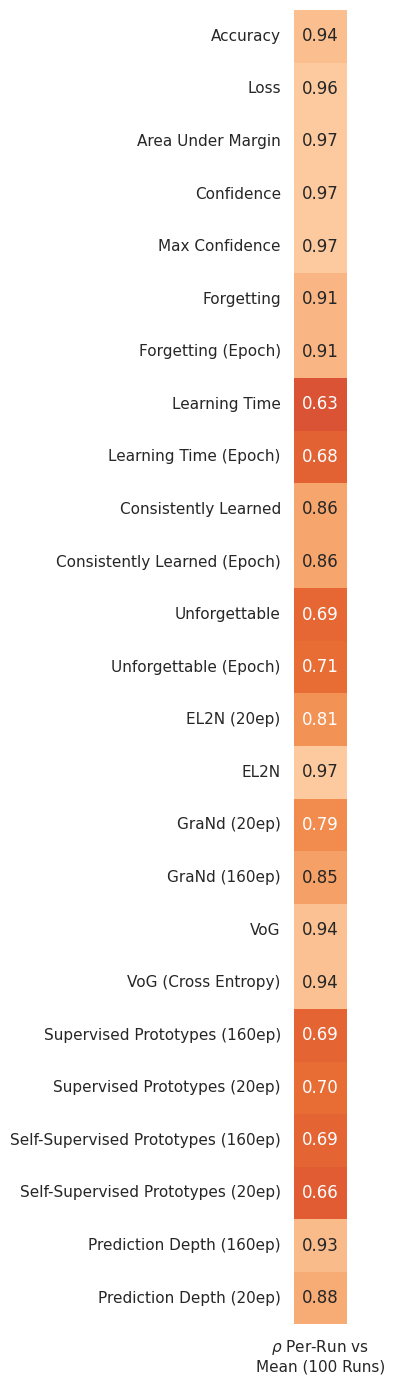

Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_selected_rank_err.pdf


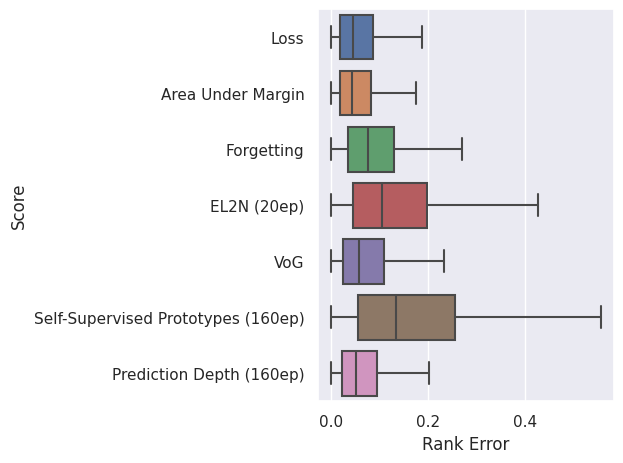

Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_rank_err.pdf


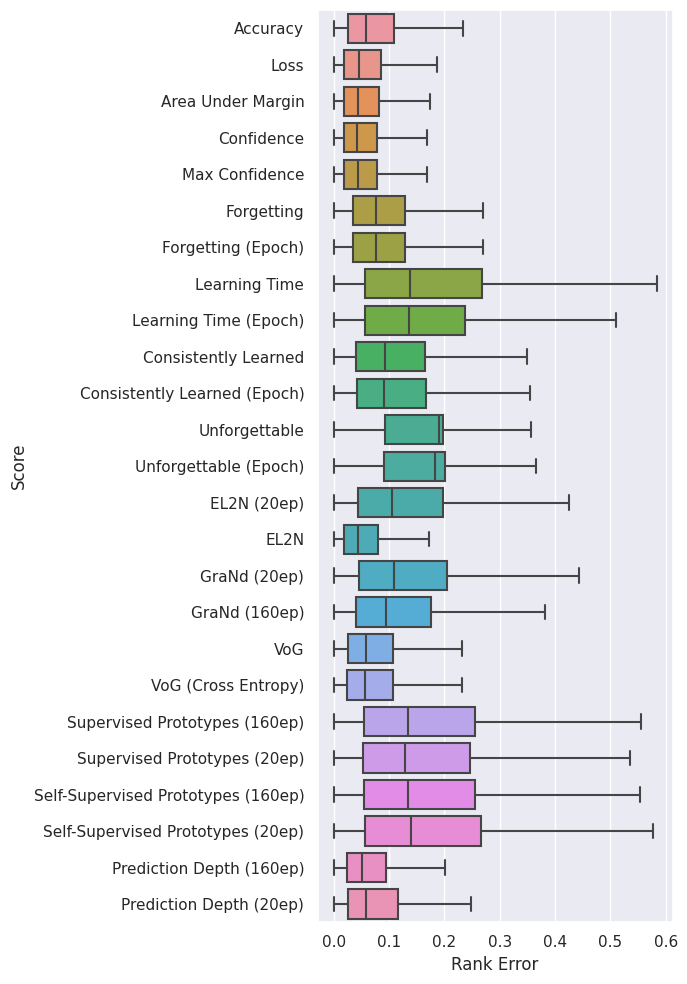

Saving figure to ../outputs/plots/var_run/CIFAR-10-ResNet-20_selected_run_subsample_err.pdf


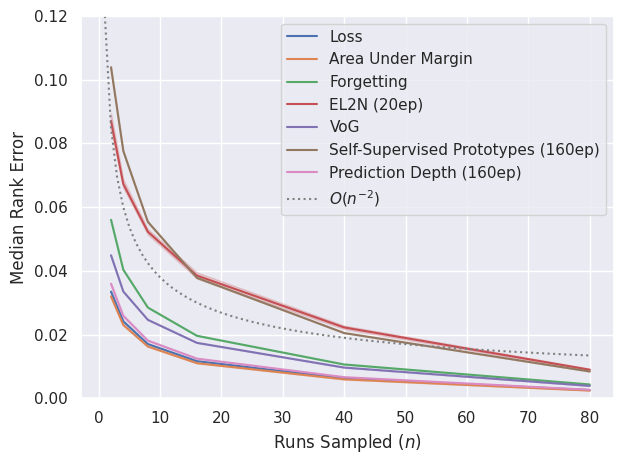

model_key                                            cifar_vgg_16
dataset_key                                               cifar10
Model                                                      VGG-16
Dataset                                                  CIFAR-10
Task                                              CIFAR-10/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_cf40a5a8bbe4f285b8...
key                      lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5
n_replicates                                                  100
Name: 8, dtype: object
Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_mean_std.pdf


<Figure size 640x480 with 0 Axes>

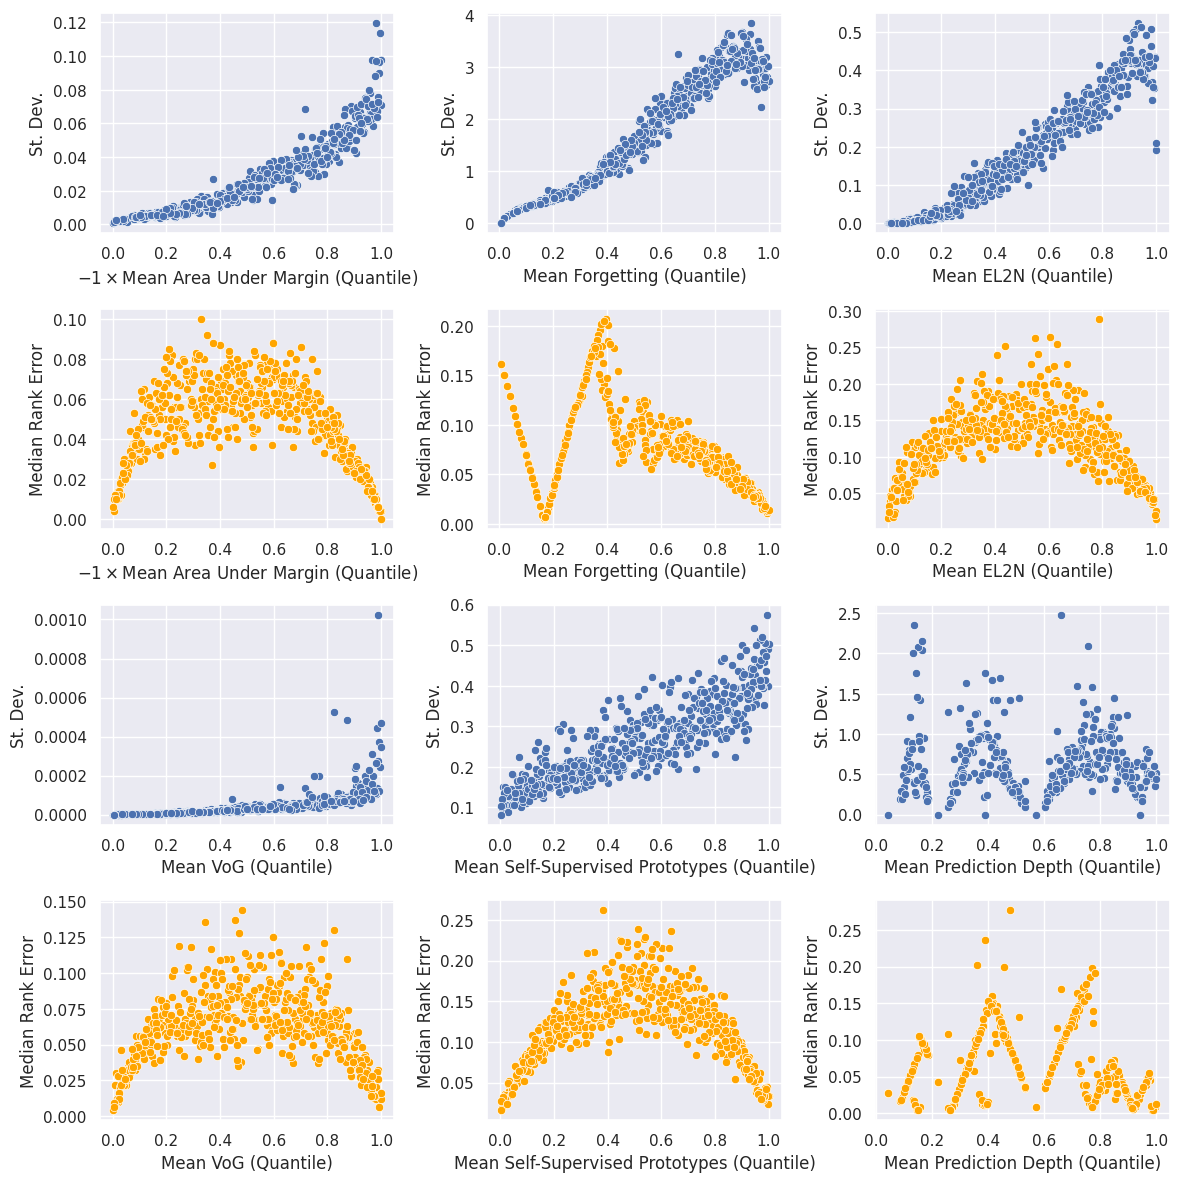

Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_selected_rank_corr.pdf


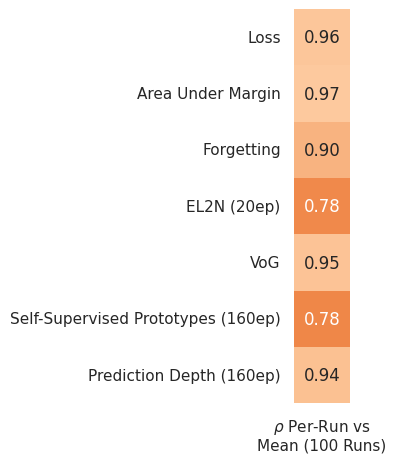

Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_rank_corr.pdf


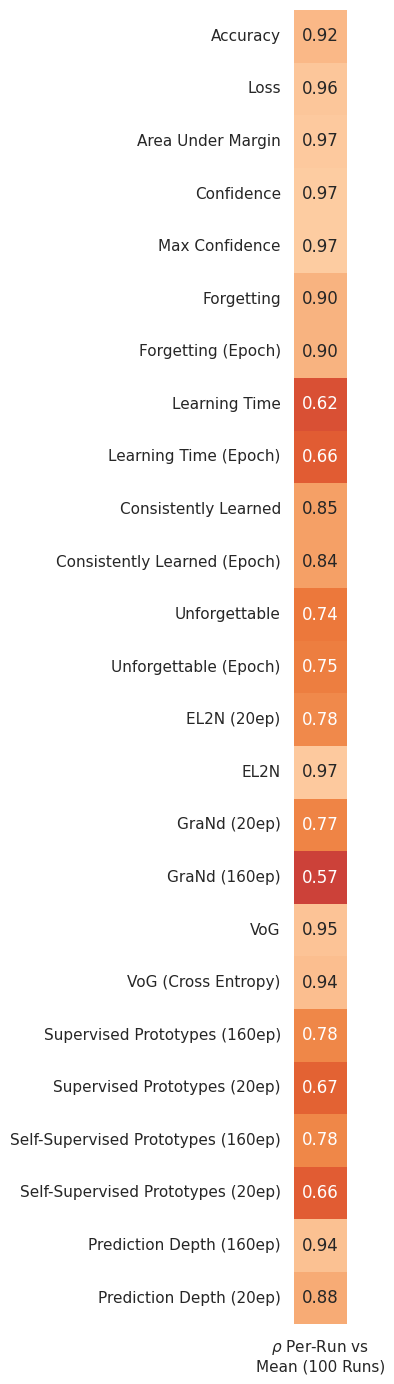

Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_selected_rank_err.pdf


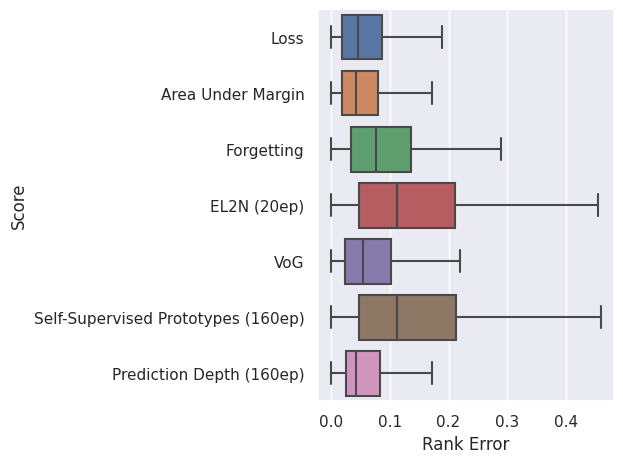

Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_rank_err.pdf


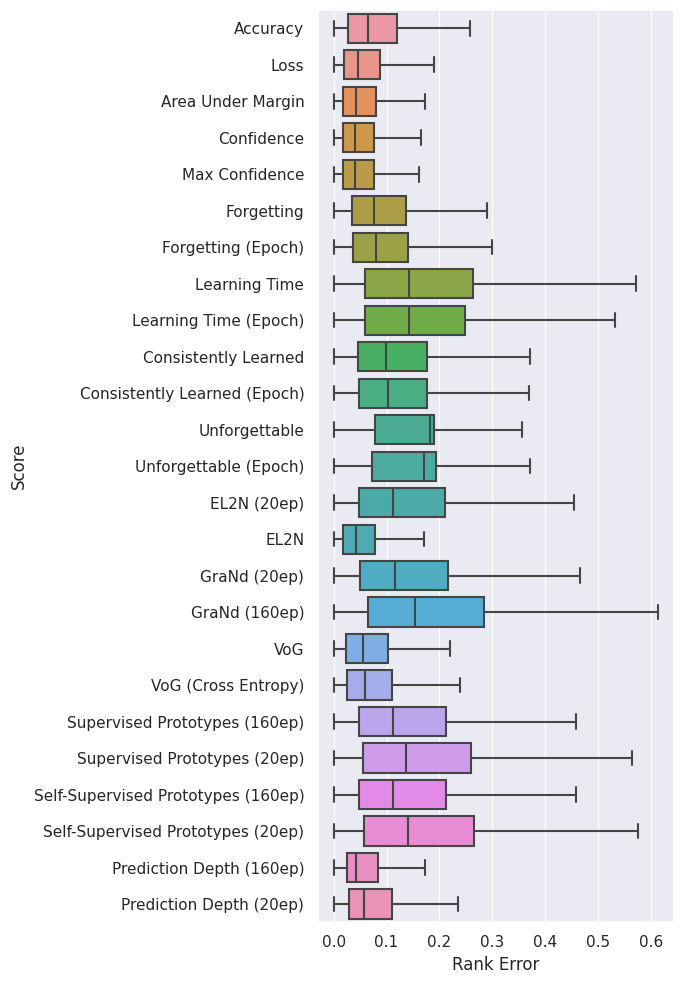

Saving figure to ../outputs/plots/var_run/CIFAR-10-VGG-16_selected_run_subsample_err.pdf


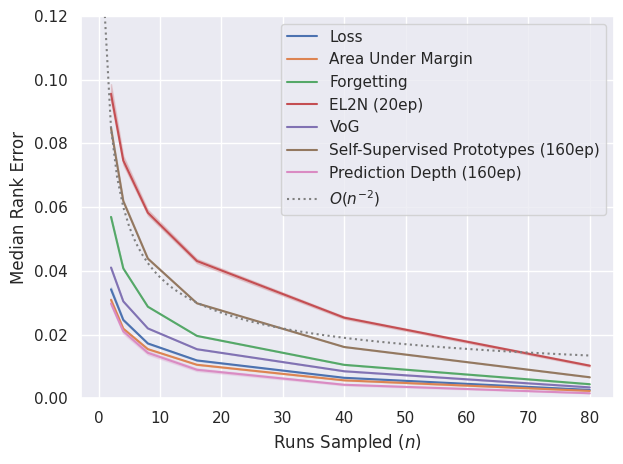

model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_06562e05cda1bf840e...
key                      lottery_06562e05cda1bf840ee146490815ed82
n_replicates                                                  100
Name: 1, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_100/level_0/main/gradmetrics/grand_20ep0it.npz: n=250, atol %=0.01470849338407377
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_43/level_0/main/gradmetrics/grand_20ep0it.npz: n=270, atol %=0.01612396276328777
Grad and ckpt 

<Figure size 640x480 with 0 Axes>

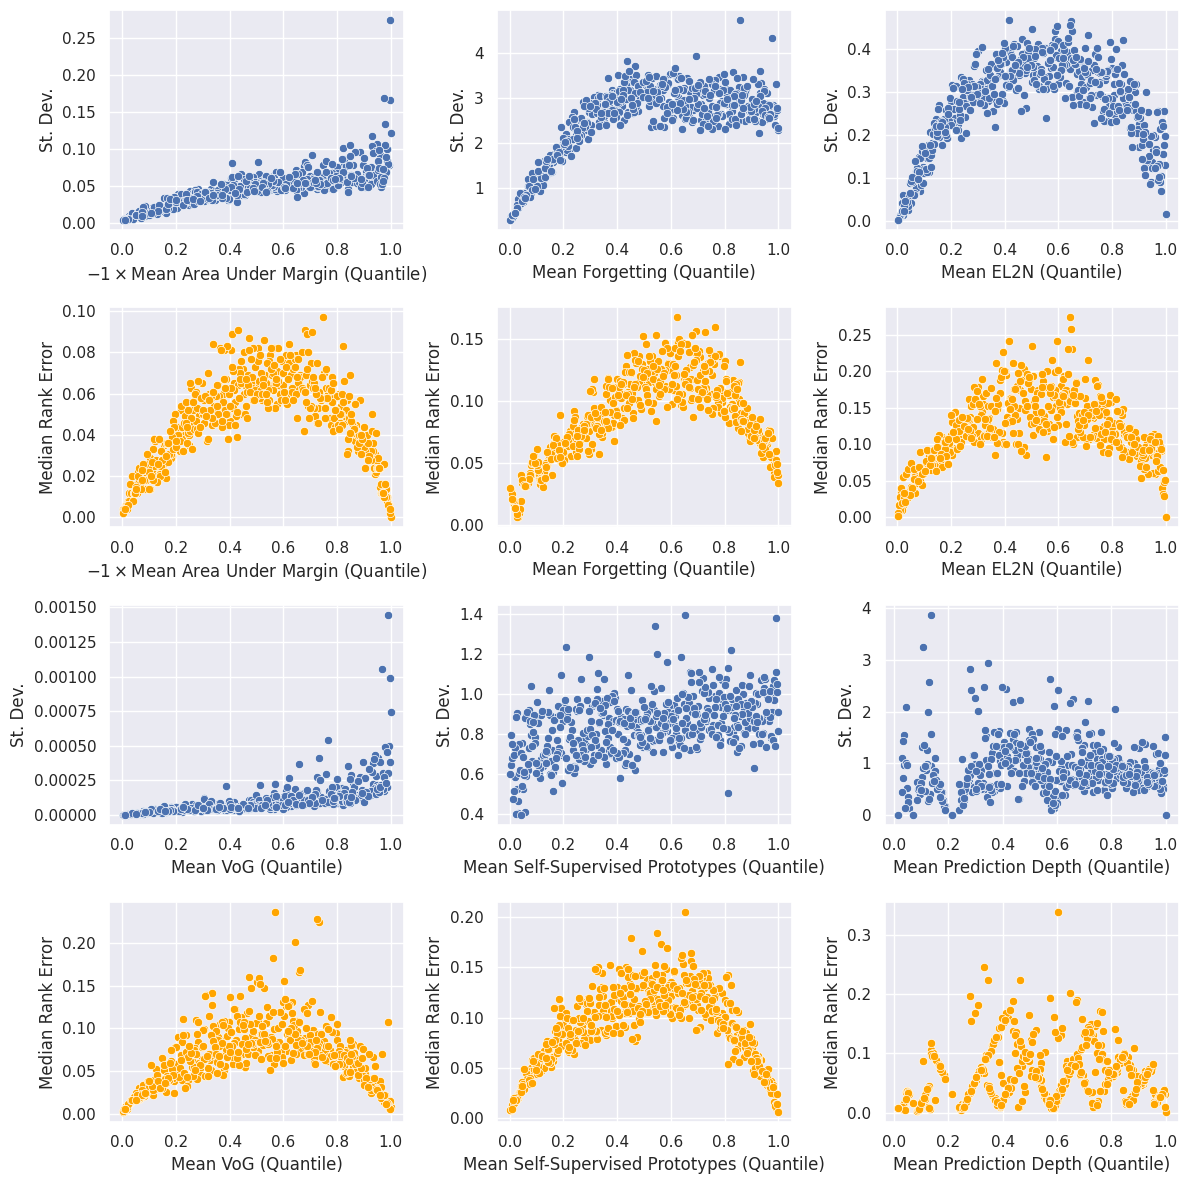

Saving figure to ../outputs/plots/var_run/CIFAR-100-VGG-16_selected_rank_corr.pdf


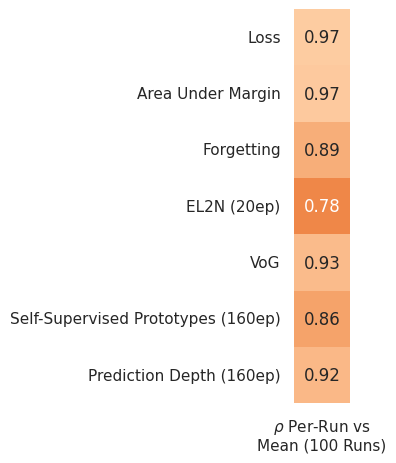

Saving figure to ../outputs/plots/var_run/CIFAR-100-VGG-16_rank_corr.pdf


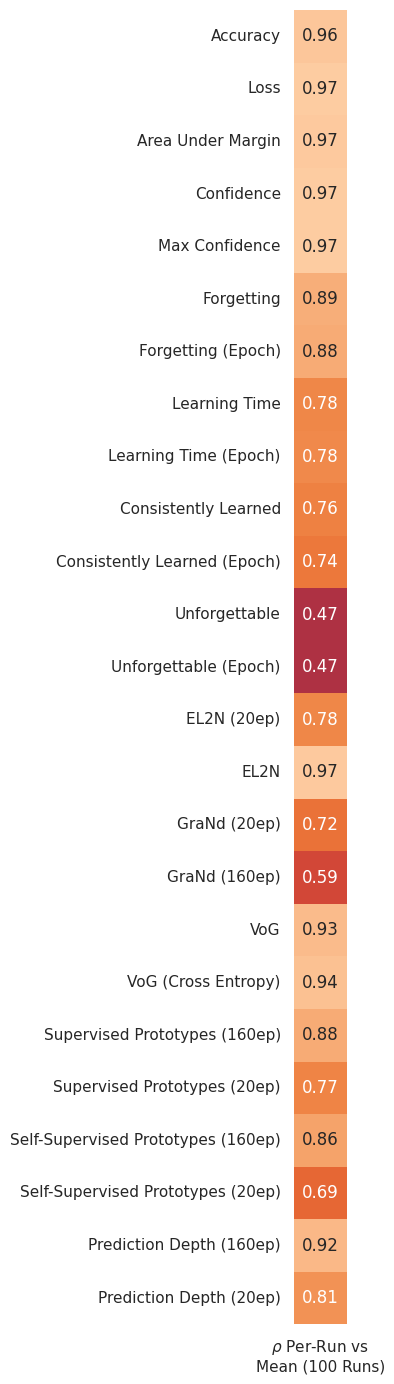

Saving figure to ../outputs/plots/var_run/CIFAR-100-VGG-16_selected_rank_err.pdf


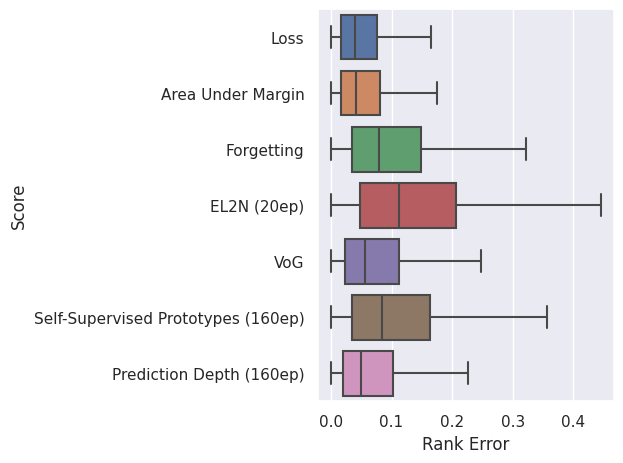

Saving figure to ../outputs/plots/var_run/CIFAR-100-VGG-16_rank_err.pdf


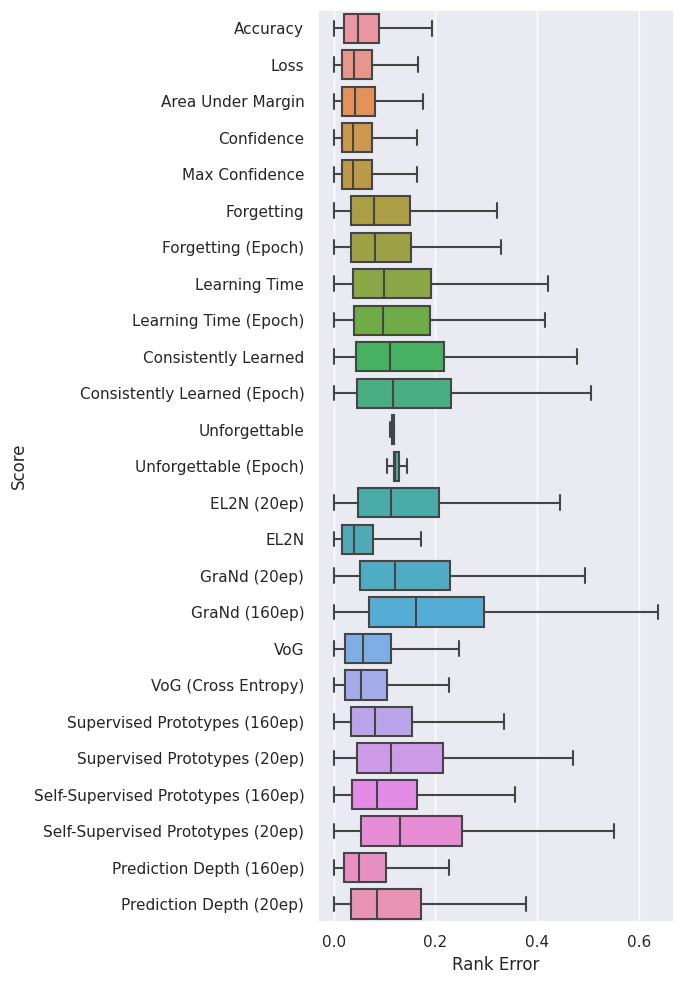

Saving figure to ../outputs/plots/var_run/CIFAR-100-VGG-16_selected_run_subsample_err.pdf


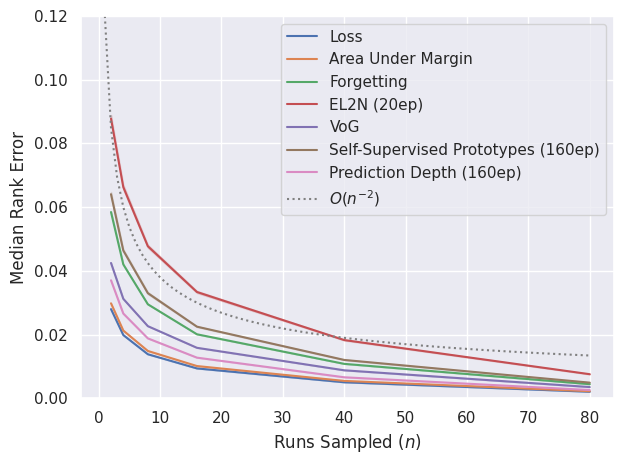

model_key                                         cifar_resnet_20
dataset_key                                              cifar100
Model                                                   ResNet-20
Dataset                                                 CIFAR-100
Task                                          CIFAR-100/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_9dc2b8dfff54c4da57...
key                      lottery_9dc2b8dfff54c4da57570d7b391dcccd
n_replicates                                                  100
Name: 6, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_54/level_0/main/gradmetrics/grand_20ep0it.npz: n=61, atol %=0.011354232836572874
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_56/level_0/main/gradmetrics/grand_20ep0it.npz: n=50, atol %=0.01291863552310424
Grad and ckpt sc

<Figure size 640x480 with 0 Axes>

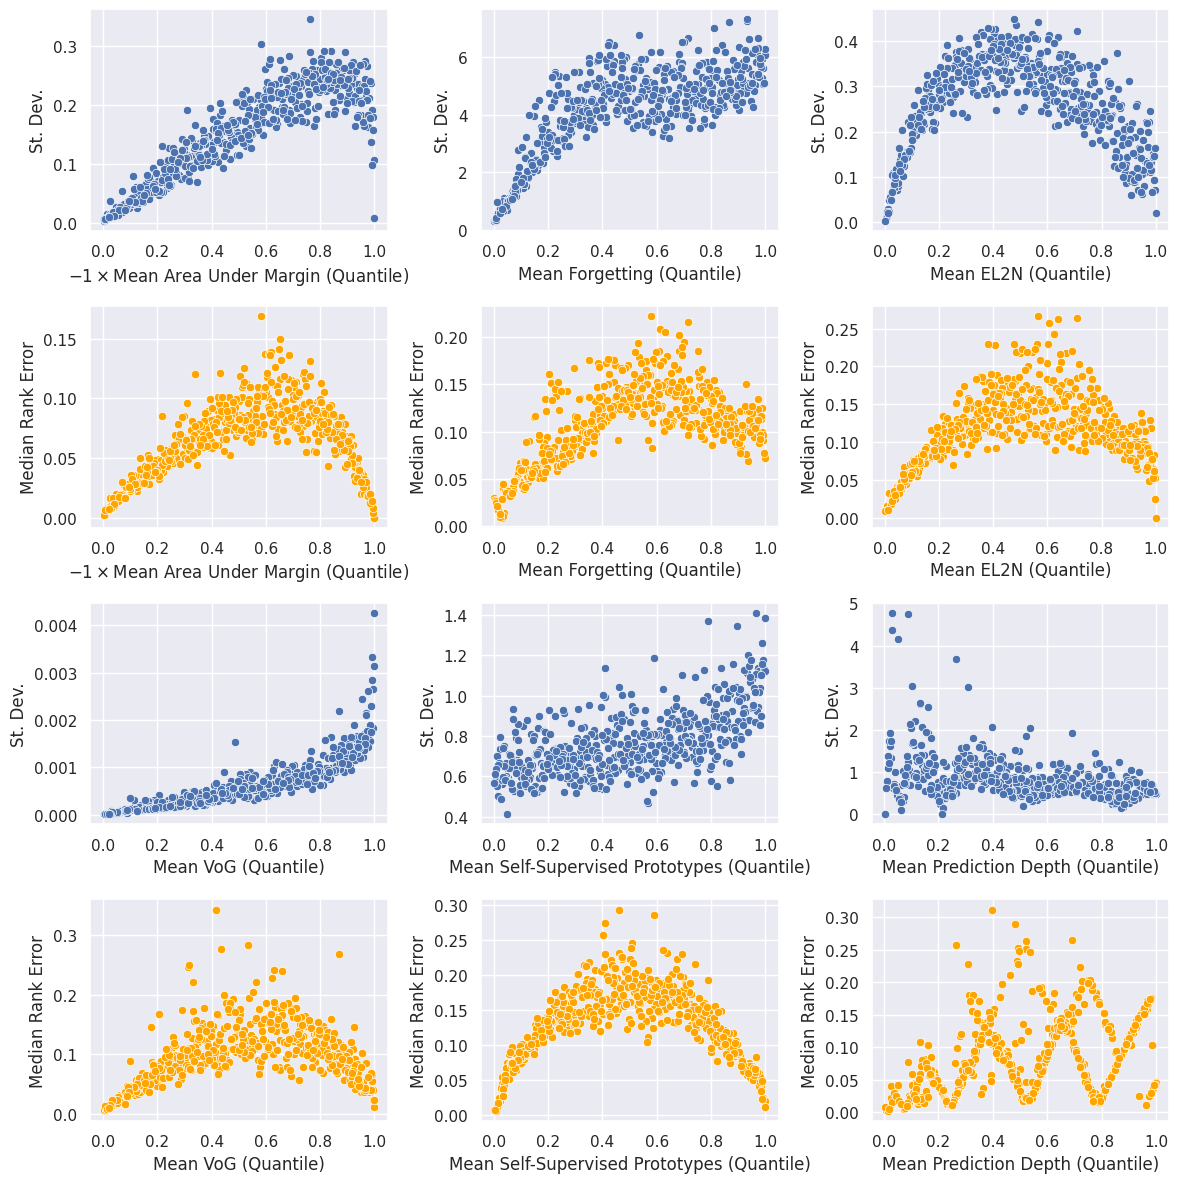

Saving figure to ../outputs/plots/var_run/CIFAR-100-ResNet-20_selected_rank_corr.pdf


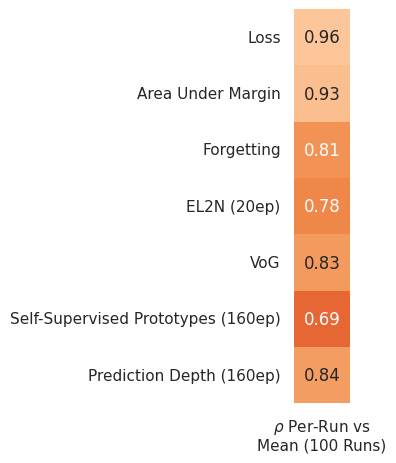

Saving figure to ../outputs/plots/var_run/CIFAR-100-ResNet-20_rank_corr.pdf


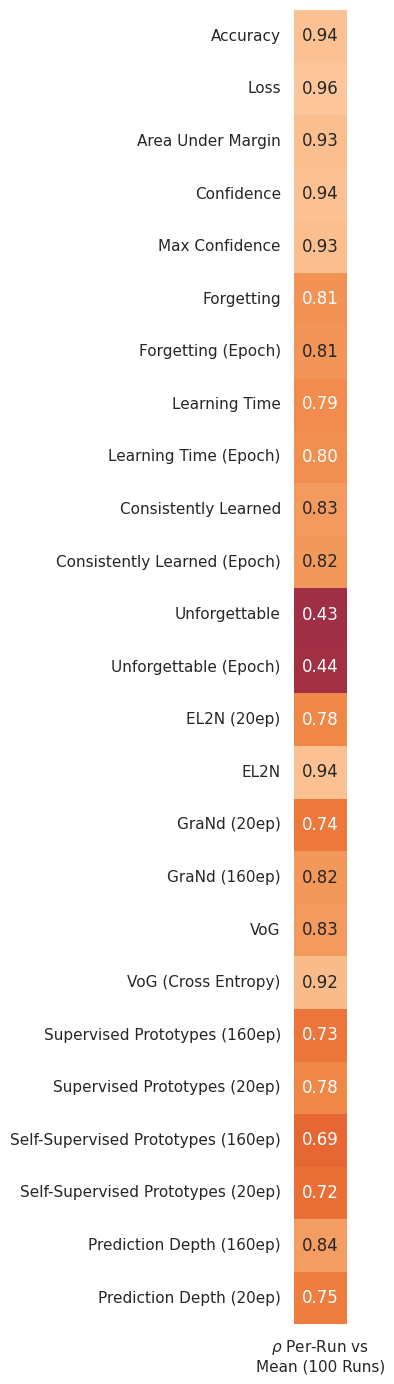

Saving figure to ../outputs/plots/var_run/CIFAR-100-ResNet-20_selected_rank_err.pdf


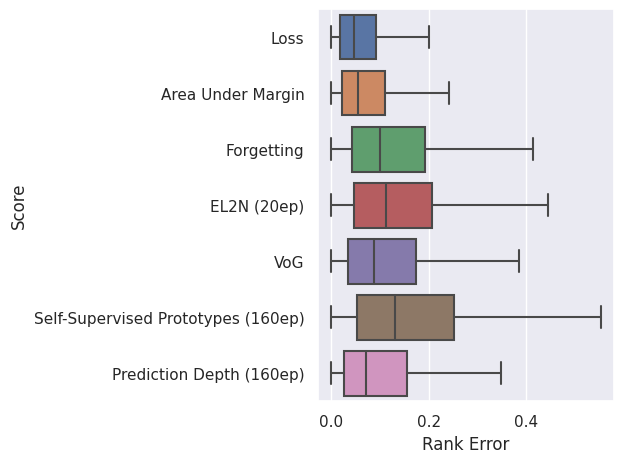

Saving figure to ../outputs/plots/var_run/CIFAR-100-ResNet-20_rank_err.pdf


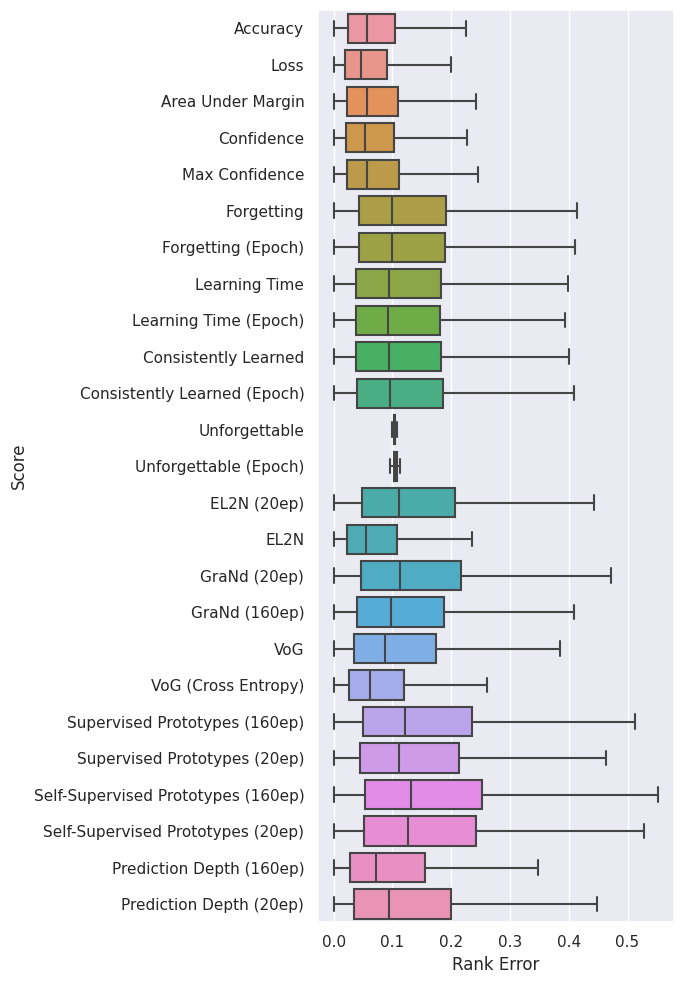

Saving figure to ../outputs/plots/var_run/CIFAR-100-ResNet-20_selected_run_subsample_err.pdf


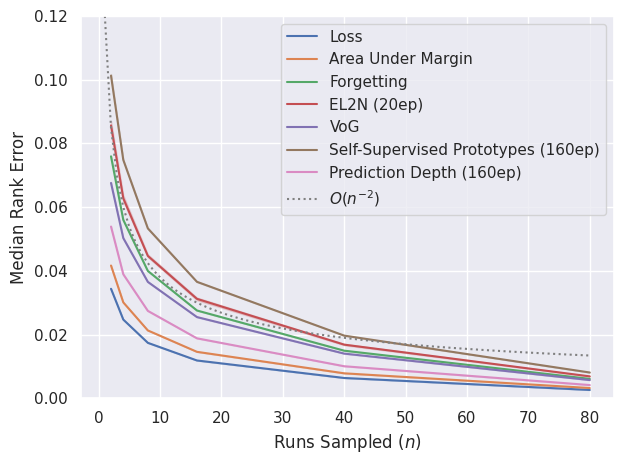

<Figure size 640x480 with 0 Axes>

In [4]:
for _, model_row in model_df.iterrows():
    print(model_row)
    sanity_checks(model_row["path"])
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS)
    score_df = score_df[score_df["Epoch"] != 0]

    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0)
    training_loss = aggregate_steps(df[df["key"] == "loss"])
    df = pd.concat([df, training_loss])
    df = df[df["Type"] == ""]

    plot_selected_stds(df, name=task_name)

    plot_run_rank_corr(df, subset_only=True, name=task_name + "_selected")
    plot_run_rank_corr(df, subset_only=False, name=task_name)
    
    plot_run_rank_err(df, subset_only=True, name=task_name + "_selected")
    plot_run_rank_err(df, subset_only=False, name=task_name)
    
    plot_run_subsample_err(df, subset_only=True, name=task_name + "_selected")